In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import sklearn

features = pd.read_csv('../features.csv')
database = pd.read_csv('../nanopore_trace_database.csv')

# Visualization of Mean Current Distribution and other features to see what features can be used for classification

### Mean Current

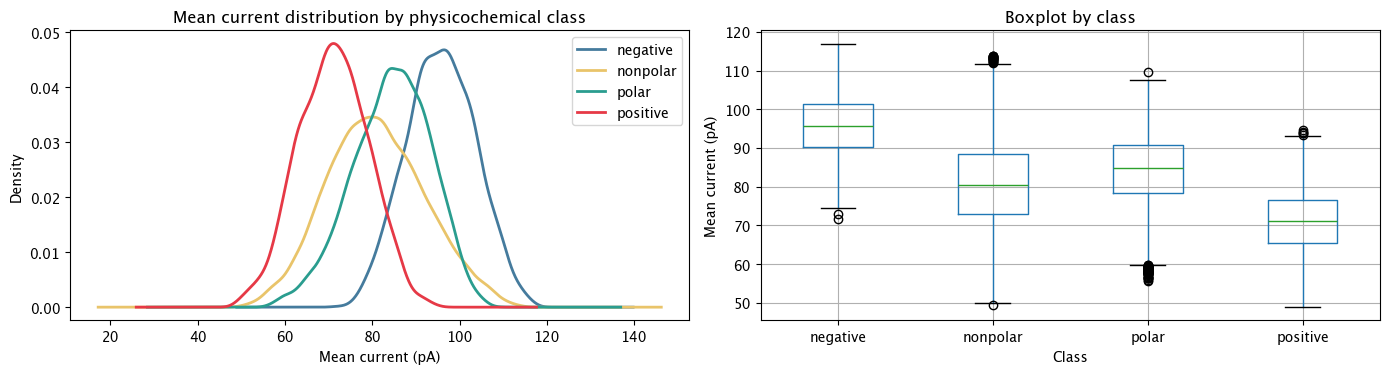

              count   mean    std    min    25%    50%     75%     max
phys_class                                                            
negative     4003.0  95.73   7.85  71.64  90.29  95.76  101.38  117.01
nonpolar    17916.0  80.89  11.13  49.45  72.99  80.46   88.47  113.91
polar       14048.0  84.36   8.92  55.59  78.38  84.82   90.86  109.76
positive     4028.0  71.05   7.97  48.85  65.36  71.09   76.51   94.66


In [12]:
CLASS_COLORS = {
    'positive': '#e63946',
    'negative': '#457b9d',
    'polar':    '#2a9d8f',
    'nonpolar': '#e9c46a',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: KDE per class overlaid
ax = axes[0]
for cls, grp in features.groupby('phys_class'):
    grp['mean_current'].plot.kde(ax=ax, label=cls, color=CLASS_COLORS[cls], linewidth=2)
ax.set_xlabel('Mean current (pA)')
ax.set_title('Mean current distribution by physicochemical class')
ax.legend()

# Right: boxplot per class
ax = axes[1]
order = ['positive', 'negative', 'polar', 'nonpolar']
features.boxplot(column='mean_current', by='phys_class', ax=ax,
           positions=range(len(order)), labels=order)
ax.set_xlabel('Class')
ax.set_ylabel('Mean current (pA)')
ax.set_title('Boxplot by class')
plt.suptitle('')
plt.tight_layout()
plt.show()

# Print summary stats
print(features.groupby('phys_class')['mean_current'].describe().round(2))

### Standard Deviation

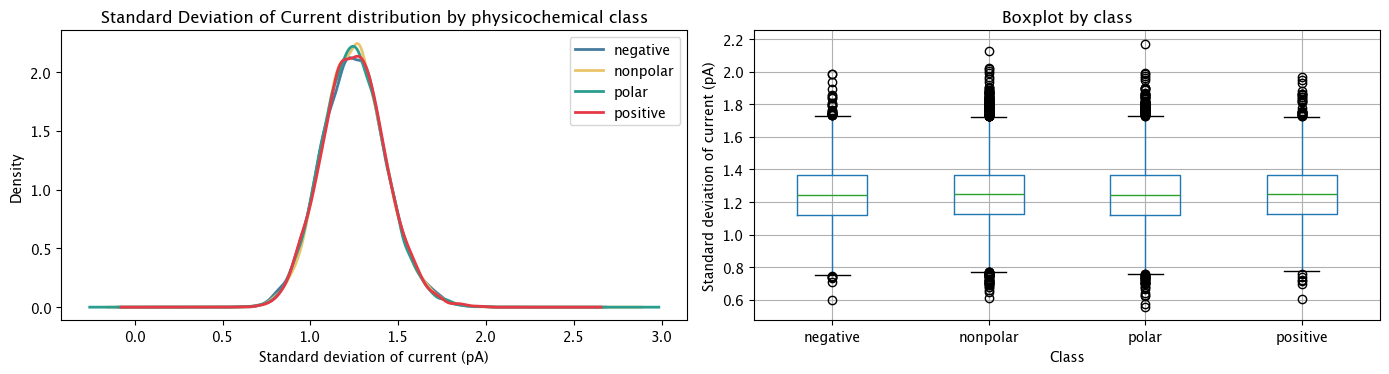

              count  mean   std   min   25%   50%   75%   max
phys_class                                                   
negative     4003.0  1.25  0.18  0.60  1.12  1.24  1.36  1.99
nonpolar    17916.0  1.25  0.18  0.61  1.13  1.25  1.37  2.13
polar       14048.0  1.25  0.18  0.55  1.12  1.24  1.36  2.17
positive     4028.0  1.25  0.18  0.60  1.13  1.25  1.37  1.97


In [13]:
CLASS_COLORS = {
    'positive': '#e63946',
    'negative': '#457b9d',
    'polar':    '#2a9d8f',
    'nonpolar': '#e9c46a',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: KDE per class overlaid
ax = axes[0]
for cls, grp in features.groupby('phys_class'):
    grp['std_current'].plot.kde(ax=ax, label=cls, color=CLASS_COLORS[cls], linewidth=2)
ax.set_xlabel('Standard deviation of current (pA)')
ax.set_title('Standard Deviation of Current distribution by physicochemical class')
ax.legend()

# Right: boxplot per class
ax = axes[1]
order = ['positive', 'negative', 'polar', 'nonpolar']
features.boxplot(column='std_current', by='phys_class', ax=ax,
           positions=range(len(order)), labels=order)
ax.set_xlabel('Class')
ax.set_ylabel('Standard deviation of current (pA)')
ax.set_title('Boxplot by class')
plt.suptitle('')
plt.tight_layout()
plt.show()

# Print summary stats
print(features.groupby('phys_class')['std_current'].describe().round(2))

### Dwell Time

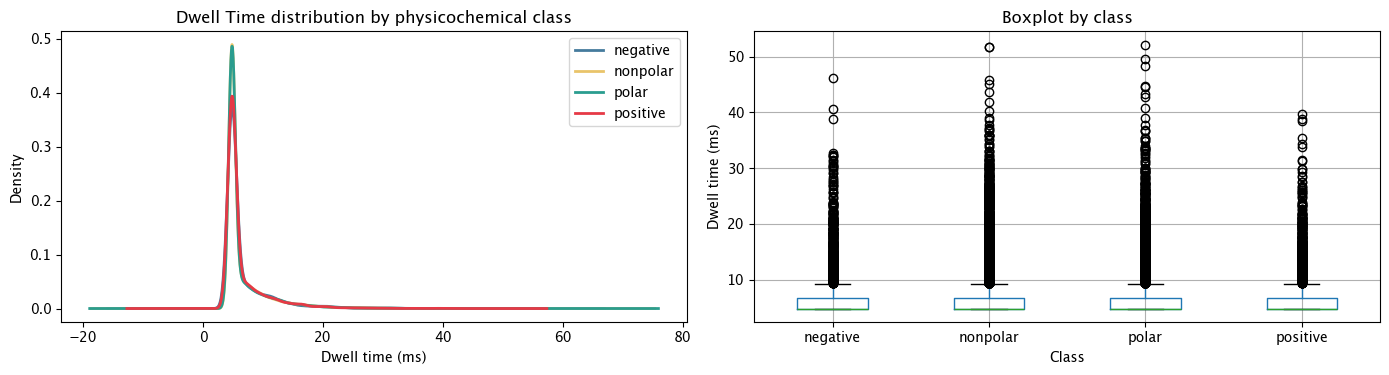

              count  mean   std  min  25%  50%  75%   max
phys_class                                               
negative     4003.0  6.63  3.97  4.8  4.8  4.8  6.6  46.2
nonpolar    17916.0  6.63  3.95  4.8  4.8  4.8  6.6  51.8
polar       14048.0  6.57  3.84  4.8  4.8  4.8  6.6  52.2
positive     4028.0  6.55  3.74  4.8  4.8  4.8  6.6  39.8


In [14]:
CLASS_COLORS = {
    'positive': '#e63946',
    'negative': '#457b9d',
    'polar':    '#2a9d8f',
    'nonpolar': '#e9c46a',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: KDE per class overlaid
ax = axes[0]
for cls, grp in features.groupby('phys_class'):
    grp['dwell_time'].plot.kde(ax=ax, label=cls, color=CLASS_COLORS[cls], linewidth=2)
ax.set_xlabel('Dwell time (ms)')
ax.set_title('Dwell Time distribution by physicochemical class')
ax.legend()

# Right: boxplot per class
ax = axes[1]
order = ['positive', 'negative', 'polar', 'nonpolar']
features.boxplot(column='dwell_time', by='phys_class', ax=ax,
           positions=range(len(order)), labels=order)
ax.set_xlabel('Class')
ax.set_ylabel('Dwell time (ms)')
ax.set_title('Boxplot by class')
plt.suptitle('')
plt.tight_layout()
plt.show()

# Print summary stats
print(features.groupby('phys_class')['dwell_time'].describe().round(2))

# Define order and mapping of classes and corresponding colors

In [15]:
# # color mapping for 4 amino acid classes
CLASS_COLORS_4 = {
    'nonpolar': 'steelblue',
    'polar': 'orange',
    'positive': 'green',
    'negative': 'red'
}

# CLASS_COLORS_3 = {
#     'positive': 'green',
#     'negative': 'red',
#     'other': 'grey'

# }

ORDER_4 = ['positive','nonpolar','polar','negative']

# ORDER_3 = ['positive','negative','other']



### Map both nonpolar and polar amino aicds to the 'other' class based on current distribution

In [29]:
# features['class3'] = features['phys_class'].replace({'polar': 'other', 'nonpolar': 'other'})
# features['phys_class']

<Axes: xlabel='mean_current', ylabel='Density'>

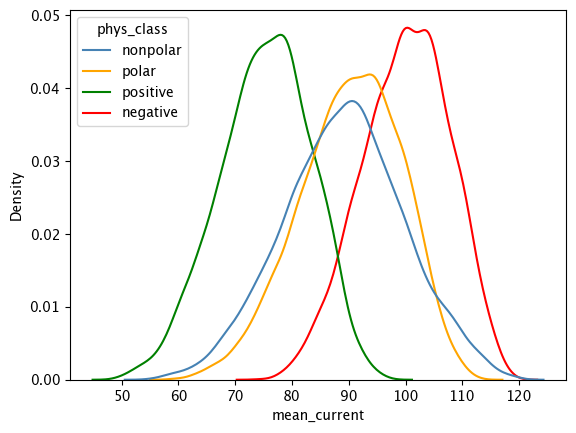

In [30]:
sns.kdeplot(data=features, x = 'mean_current', hue='phys_class', palette=CLASS_COLORS_4, common_norm=False)

### Summary statistics per class

In [31]:
stats_table = features.groupby('phys_class')['mean_current'].agg(
    n='count',
    mean='mean',
    std='std',
    p5=lambda x: x.quantile(0.05),
    p25=lambda x: x.quantile(0.25),
    median='median',
    p75=lambda x: x.quantile(0.75),
    p95=lambda x: x.quantile(0.95),
).round(2)

stats_table

,n,mean,std,p5,p25,median,p75,p95
phys_class,,,,,,,,
negative,3974,100.02,7.68,86.71,94.74,100.36,105.57,111.97
nonpolar,18040,89.09,10.68,71.15,81.90,89.31,96.27,107.05
polar,14008,90.25,8.97,74.54,84.27,90.77,96.86,103.86
positive,3973,75.21,8.06,61.12,69.83,75.65,80.90,87.72


### Scatter of std_current and dwell_time by class — no discriminative signal

In [32]:
# fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# for cls in ORDER_3:
#     subset = features[features['class3'] == cls]
#     axes[0].scatter(subset['mean_current'], subset['std_current'],
#                     color=CLASS_COLORS_3[cls], alpha=0.2, s=5, label=cls)
#     axes[1].scatter(subset['mean_current'], subset['dwell_time'],
#                     color=CLASS_COLORS_3[cls], alpha=0.2, s=5, label=cls)

# axes[0].set_xlabel('Mean current (pA)')
# axes[0].set_ylabel('Std current')
# axes[0].set_title('std_current vs mean_current')
# axes[0].legend()

# axes[1].set_xlabel('Mean current (pA)')
# axes[1].set_ylabel('Dwell time')
# axes[1].set_title('dwell_time vs mean_current')
# axes[1].legend()

# plt.tight_layout()
# plt.show()

### KDE overlap quantification between class pairs

In [33]:
# from scipy.stats import gaussian_kde
# from itertools import combinations

# x = np.linspace(features['mean_current'].min() - 5, features['mean_current'].max() + 5, 1000)

# # fit a KDE per class
# kdes = {}
# for cls in ORDER_3:
#     vals = features.loc[features['class3'] == cls, 'mean_current'].values
#     kdes[cls] = gaussian_kde(vals)(x)

# # compute pairwise overlap
# print("Pairwise KDE overlap (0 = no overlap, 1 = identical):")
# for cls_a, cls_b in combinations(ORDER_3, 2):
#     overlap = np.trapezoid(np.minimum(kdes[cls_a], kdes[cls_b]), x)
#     print(f"  {cls_a} vs {cls_b}: {overlap:.4f}")

# See if i can use grid search to find thresholds for cutting off positive, negative, and other current

In [34]:
# classify a step with two cut-off values

# if mean_current < t1: classify as positive
# if mean_current > t2: classify as negative
# else classify as other


# do a grid search to find optimal t1 and t2 that maximize classification accuracy

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

t1range = np.arange(40, 100, 0.5)
t2range = np.arange(60, 130, 0.5)
best_acc = 0
best_t1, best_t2 = None, None

conditions = [
    features['mean_current'] < best_t1,
    features['mean_current'] > best_t2
]
choices = ['positive', 'negative']
preds = np.select(conditions, choices, default='other'
                  )




for t1 in t1range:
    for t2 in t2range:
        if t1>=t2:
            continue
        conditions = [
            features['mean_current'] < t1,
            features['mean_current'] > t2
            ]
        choices = ['positive', 'negative']
        preds = np.select(conditions, choices, default='other'
                  )
        score = f1_score(features['phys_class'], preds, average='weighted', labels=['positive', 'negative'], zero_division=0)
        if score >best_acc:
            best_acc = score 
            best_t1, best_t2 = t1, t2


print(f"Best F1 score: {best_acc:.4f} with t1={best_t1} and t2={best_t2}")

        # need to apply the thresholds to generate predicitons for every row
        # score them against the true labels
        # track the best score


KeyboardInterrupt: 

## Final classification report using the final predictions generated with the best t1 and t2 w the grid search

In [ ]:
conditions = [
    features['mean_current'] < best_t1,
    features['mean_current'] > best_t2,
]
final_preds = np.select(conditions, ['positive', 'negative'], default='other')

print(classification_report(features['phys_class'], final_preds, labels=['positive', 'negative'], zero_division=0))


In [ ]:
cm = confusion_matrix(features['phys_class'], final_preds, labels=ORDER_4)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=ORDER_4, yticklabels=ORDER_4)


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

# KDE
sns.kdeplot(data=features, x='mean_current', hue='phys_class', 
            palette=CLASS_COLORS_4, common_norm=False, ax=ax)

# threshold lines
ax.axvline(best_t1, color='black', linestyle='--', label=f't1={best_t1:.1f}')
ax.axvline(best_t2, color='black', linestyle=':',  label=f't2={best_t2:.1f}')

# shaded decision regions
ax.axvspan(ax.get_xlim()[0], best_t1, alpha=0.1, color=CLASS_COLORS_4['positive'])
ax.axvspan(best_t1, best_t2,           alpha=0.1, color='grey')
ax.axvspan(best_t2, ax.get_xlim()[1], alpha=0.1, color=CLASS_COLORS_4['negative'])

ax.legend()
plt.show()


In [16]:
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# feature_cols = [
#     'mean_minus2', 'std_minus2', 'dwell_minus2',
#     'mean_minus1', 'std_minus1', 'dwell_minus1',
#     'mean_current', 'std_current', 'dwell_time',
#     'mean_plus1', 'std_plus1', 'dwell_plus1',
#     'mean_plus2', 'std_plus2', 'dwell_plus2',
# ]
feature_cols = [
    'mean_minus2', 'std_minus2',
    'mean_minus1', 'std_minus1',
    'mean_current','std_current',
    'mean_plus1', 'std_plus1',
    'mean_plus2', 'std_plus2'
]


X = features[feature_cols].values
y = features['phys_class'].values
mask = ~np.isnan(X).any(axis=1)
X, y = X[mask], y[mask]

models = {
    'GaussianNB': GaussianNB(),
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced'))
    ]),
    'RandomForest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
}

### Classifying with machine elarning models instead, with 5-fold cross validation


* used a Gaussian Naive Bayes Classifer, Random Forest Classifier, and Logistic Regression(???)



In [17]:
from sklearn.model_selection import StratifiedKFold, cross_validate

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'macro_f1':    'f1_macro',
    'weighted_f1': 'f1_weighted',
    'accuracy':    'accuracy',
}

cv_results = {}
for name, model in models.items():
    result = cross_validate(model, X, y, cv=kf, scoring=scoring)
    cv_results[name] = {
        'macro F1':    (result['test_macro_f1'].mean(),    result['test_macro_f1'].std()),
        'weighted F1': (result['test_weighted_f1'].mean(), result['test_weighted_f1'].std()),
        'accuracy':    (result['test_accuracy'].mean(),    result['test_accuracy'].std()),
    }

# summary table: mean ± std across folds
rows = {}
for name, metrics in cv_results.items():
    rows[name] = {metric: f"{mean:.3f} ± {std:.3f}" for metric, (mean, std) in metrics.items()}

pd.DataFrame(rows).T

,macro F1,weighted F1,accuracy
GaussianNB,0.378 ± 0.008,0.403 ± 0.005,0.398 ± 0.006
LogisticRegression,0.522 ± 0.004,0.509 ± 0.004,0.517 ± 0.004
RandomForest,0.401 ± 0.004,0.488 ± 0.002,0.511 ± 0.001


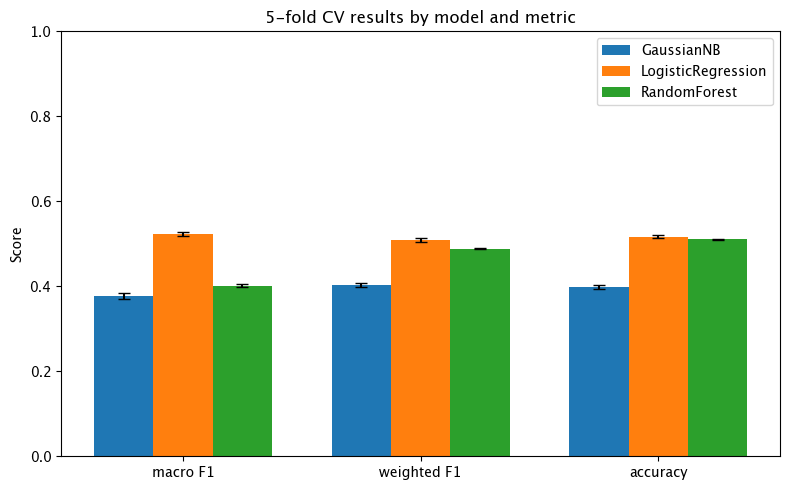

In [18]:
metrics = ['macro F1', 'weighted F1', 'accuracy']
model_names = list(cv_results.keys())
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))

for i, name in enumerate(model_names):
    means = [cv_results[name][m][0] for m in metrics]
    stds  = [cv_results[name][m][1] for m in metrics]
    ax.bar(x + i * width, means, width, yerr=stds, label=name, capsize=4)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('5-fold CV results by model and metric')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

#### Visualize the diference ins euqnec eof the peptide

In [19]:
from sklearn.model_selection import cross_val_predict

# get out-of-fold predictions for each model using the same CV split
# for name, model in models.items():
#     features[f'pred_{name}'] = cross_val_predict(model, X, y, cv=kf)
for name, model in models.items():
    preds = cross_val_predict(model, X, y, cv=kf)
    features.loc[mask, f'pred_{name}'] = preds

# show one trace as an example
trace = features[features['trace_id'] == 0].dropna(subset=[f'pred_{name}' for name in models]).sort_values('step_id')
for name in models:
    acc = (trace[f'pred_{name}'] == trace['phys_class']).mean()
    print(f"{name:20s} (acc={acc:.2f}): {' - '.join(trace[f'pred_{name}'].tolist())}")
print(f"{'actual':20s}         : {' - '.join(trace['phys_class'].tolist())}")
print(f"{'amino acid':20s}         : {' - '.join(trace['amino_acid'].tolist())}")

GaussianNB           (acc=0.44): positive - positive - nonpolar - polar - nonpolar - nonpolar - polar - negative - negative - nonpolar - nonpolar - nonpolar - polar - polar - polar - polar
LogisticRegression   (acc=0.50): positive - positive - nonpolar - negative - polar - positive - nonpolar - negative - negative - nonpolar - positive - positive - negative - nonpolar - nonpolar - polar
RandomForest         (acc=0.44): nonpolar - nonpolar - polar - negative - nonpolar - nonpolar - polar - negative - negative - polar - nonpolar - nonpolar - negative - polar - nonpolar - polar
actual                       : positive - polar - polar - polar - polar - nonpolar - nonpolar - negative - polar - polar - positive - nonpolar - negative - nonpolar - polar - polar
amino acid                   : R - Y - H - N - Q - F - M - D - S - C - R - L - D - M - H - H


Diff way to visualize the diffs in sequence of classes of the peptides

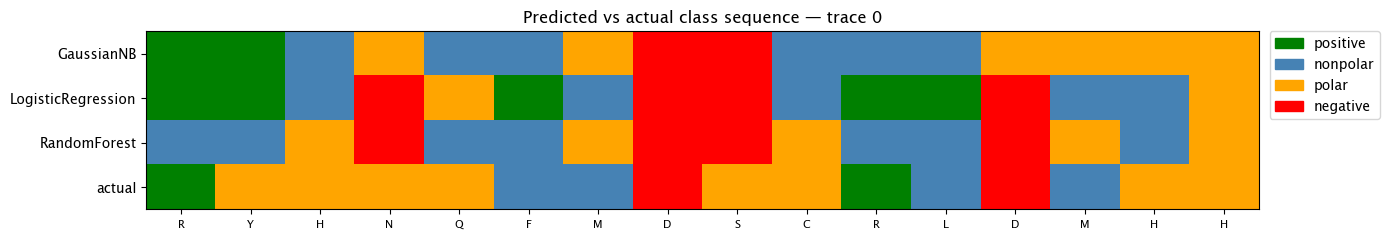

In [20]:
import matplotlib
from matplotlib.patches import Patch

CLASS_INT = {'positive': 0, 'nonpolar': 1, 'polar': 2, 'negative': 3}
CMAP = matplotlib.colors.ListedColormap([CLASS_COLORS_4['positive'], CLASS_COLORS_4['nonpolar'], CLASS_COLORS_4['polar'], CLASS_COLORS_4['negative']])

rows = {name: trace[f'pred_{name}'].map(CLASS_INT).values for name in models}
rows['actual'] = trace['phys_class'].map(CLASS_INT).values
grid = np.array(list(rows.values()))

fig, ax = plt.subplots(figsize=(14, 2.5))
ax.imshow(grid, aspect='auto', cmap=CMAP, vmin=0, vmax=3, interpolation='none')

ax.set_yticks(range(len(rows)))
ax.set_yticklabels(list(rows.keys()))
ax.set_xticks(range(len(trace)))
ax.set_xticklabels(trace['amino_acid'].tolist(), fontsize=8)

legend = [Patch(color=CLASS_COLORS_4[c], label=c) for c in ORDER_4]
ax.legend(handles=legend, bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)

ax.set_title('Predicted vs actual class sequence — trace 0')
plt.tight_layout()
plt.show()


#### Accuracy of each amino acid classified per model

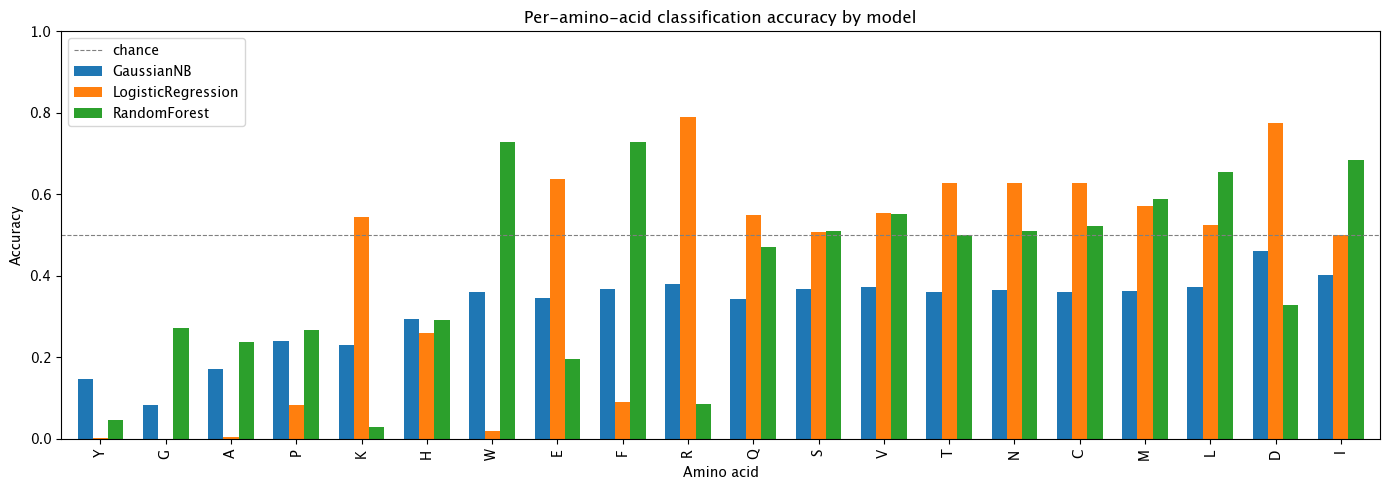

In [21]:
aa_acc = {}
for name in models:
    aa_acc[name] = (
        features.groupby('amino_acid')
        .apply(lambda df: (df[f'pred_{name}'] == df['phys_class']).mean())
        .rename(name)
    )

aa_df = pd.concat(aa_acc, axis=1)

# sort by mean accuracy across models (worst performers on the left)
aa_df = aa_df.loc[aa_df.mean(axis=1).sort_values().index]

ax = aa_df.plot(kind='bar', figsize=(14, 5), width=0.7)
ax.set_xlabel('Amino acid')
ax.set_ylabel('Accuracy')
ax.set_title('Per-amino-acid classification accuracy by model')
ax.set_ylim(0, 1)
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, label='chance')
ax.legend()
plt.tight_layout()
plt.show()


In Numbers

In [22]:
print('Random Forest:', aa_acc['RandomForest'].sort_values())

Random Forest: amino_acid
K    0.029382
Y    0.045742
R    0.085644
E    0.196917
A    0.236762
P    0.268209
G    0.271635
H    0.292486
D    0.327309
Q    0.469583
T    0.500492
N    0.509054
S    0.509784
C    0.523430
V    0.551724
M    0.588088
L    0.654639
I    0.684577
W    0.728407
F    0.729620
Name: RandomForest, dtype: float64


In [23]:
print('Logistic Regression:', aa_acc['LogisticRegression'].sort_values())

Logistic Regression: amino_acid
G    0.000000
Y    0.002920
A    0.005601
W    0.018472
P    0.084154
F    0.091139
H    0.259708
I    0.499502
S    0.506774
L    0.524227
K    0.544323
Q    0.548517
V    0.555381
M    0.571071
C    0.626620
N    0.628270
T    0.628319
E    0.636997
D    0.774598
R    0.790099
Name: LogisticRegression, dtype: float64


In [24]:
print('Gaussian NB:', aa_acc['GaussianNB'].sort_values())

Gaussian NB: amino_acid
G    0.084135
Y    0.147932
A    0.172607
K    0.229084
P    0.240650
H    0.292990
Q    0.344394
E    0.345599
T    0.359390
C    0.359422
W    0.360459
M    0.363864
N    0.366197
S    0.366784
F    0.368608
L    0.372165
V    0.372518
R    0.379208
I    0.401990
D    0.459839
Name: GaussianNB, dtype: float64


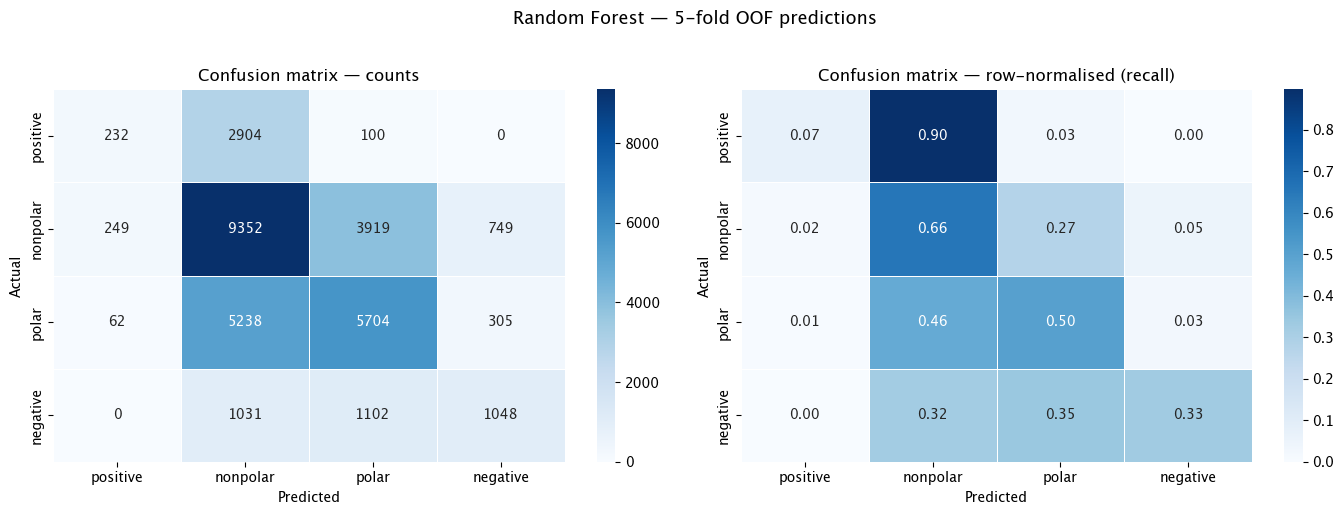

              precision    recall  f1-score   support

    positive       0.43      0.07      0.12      3236
    nonpolar       0.50      0.66      0.57     14269
       polar       0.53      0.50      0.52     11309
    negative       0.50      0.33      0.40      3181

    accuracy                           0.51     31995
   macro avg       0.49      0.39      0.40     31995
weighted avg       0.50      0.51      0.49     31995



In [25]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

valid = features.dropna(subset=['pred_RandomForest'])
y_true = valid['phys_class']
y_pred = valid['pred_RandomForest']

cm_counts = confusion_matrix(y_true, y_pred, labels=ORDER_4)
cm_norm   = cm_counts.astype(float) / cm_counts.sum(axis=1, keepdims=True)  # row-normalised (recall)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cm, title, fmt in zip(
    axes,
    [cm_counts, cm_norm],
    ['Confusion matrix — counts', 'Confusion matrix — row-normalised (recall)'],
    ['d', '.2f']
):
    sns.heatmap(
        cm, annot=True, fmt=fmt, cmap='Blues',
        xticklabels=ORDER_4, yticklabels=ORDER_4,
        linewidths=0.5, ax=ax
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)

plt.suptitle('Random Forest — 5-fold OOF predictions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, labels=ORDER_4, target_names=ORDER_4))

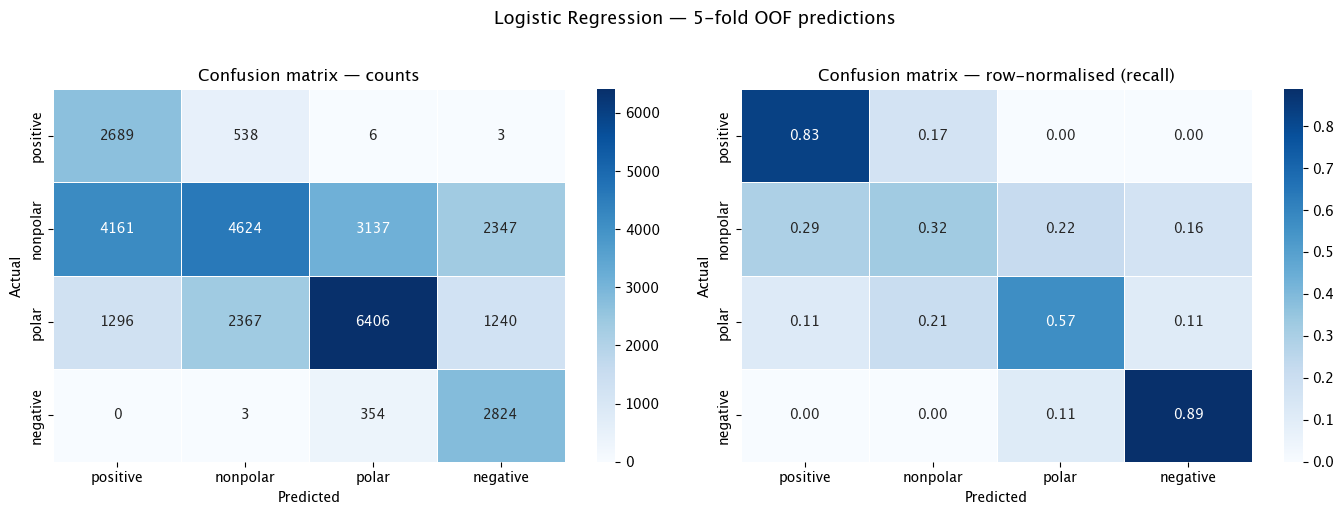

              precision    recall  f1-score   support

    positive       0.33      0.83      0.47      3236
    nonpolar       0.61      0.32      0.42     14269
       polar       0.65      0.57      0.60     11309
    negative       0.44      0.89      0.59      3181

    accuracy                           0.52     31995
   macro avg       0.51      0.65      0.52     31995
weighted avg       0.58      0.52      0.51     31995



In [26]:
valid = features.dropna(subset=['pred_LogisticRegression'])
y_true = valid['phys_class']
y_pred = valid['pred_LogisticRegression']

cm_counts = confusion_matrix(y_true, y_pred, labels=ORDER_4)
cm_norm   = cm_counts.astype(float) / cm_counts.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cm, title, fmt in zip(
    axes,
    [cm_counts, cm_norm],
    ['Confusion matrix — counts', 'Confusion matrix — row-normalised (recall)'],
    ['d', '.2f']
):
    sns.heatmap(
        cm, annot=True, fmt=fmt, cmap='Blues',
        xticklabels=ORDER_4, yticklabels=ORDER_4,
        linewidths=0.5, ax=ax
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)

plt.suptitle('Logistic Regression — 5-fold OOF predictions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, labels=ORDER_4, target_names=ORDER_4))